
# Lưu ý tập model chỉ được train và dự đoán ổn định trên tập ảnh các hạt cà phê robusta ở Việt Nam

# Link drive weight sau khi train bạn có thể tải về và chạy thử nghiệm
https://drive.google.com/file/d/1sTo57jmdWpMT2ov_AfLoYFI_I9sfmY0w/view?usp=drive_link

In [1]:
!pip install transformers

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
image_path = "/content/drive/MyDrive/TTCSDL/data_ch_1/val/good/IMG_7904.png"

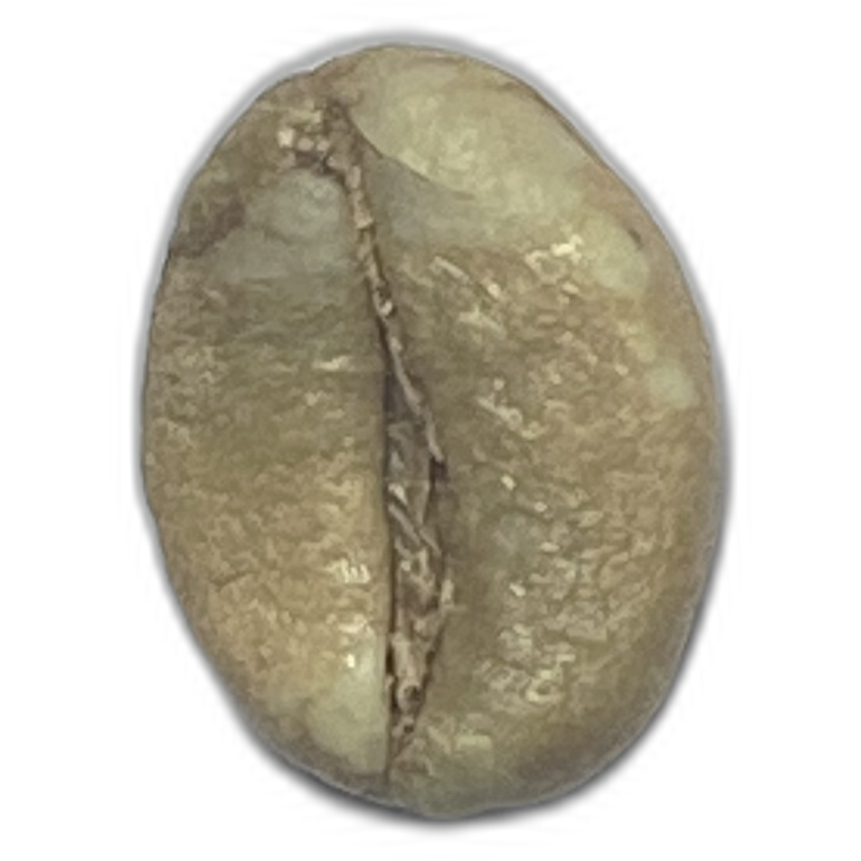

In [9]:
image = Image.open(image_path).convert("RGB")
image

In [10]:
# ===== 1. IMPORT =====
import torch
from transformers import ConvNextForImageClassification, ConvNextImageProcessor
from PIL import Image

# ===== 2. CONFIG =====
# thay thể link này bằng link drive weight bạn đã tải về
model_path = "/content/drive/MyDrive/convnext_coffee.pth"
# link ảnh dự đoán của bạn chỉ tốt với robusta ở việt nam
image_path = "/content/drive/MyDrive/TTCSDL/data_ch_1/val/good/IMG_7904.png"
num_classes = 2


class_names = ['bad', 'good']

device = "cuda" if torch.cuda.is_available() else "cpu"

# ===== 3. LOAD MODEL =====
model = ConvNextForImageClassification.from_pretrained(
    "facebook/convnext-tiny-224",
)

model.classifier = torch.nn.Linear(
    model.classifier.in_features,
    num_classes
)

model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

# ===== 4. LOAD PROCESSOR =====
processor = ConvNextImageProcessor.from_pretrained(
    "facebook/convnext-tiny-224"
)

# ===== 5. LOAD IMAGE =====
image = Image.open(image_path).convert("RGB")

# ===== 6. PREPROCESS =====
inputs = processor(images=image, return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}

# ===== 7. INFERENCE =====
with torch.no_grad():
    outputs = model(**inputs)
    probs = torch.softmax(outputs.logits, dim=1)
    pred = probs.argmax(dim=1).item()

# ===== 8. OUTPUT =====
print("Predicted class:", class_names[pred])
print("Confidence:", probs[0][pred].item())

Loading weights:   0%|          | 0/182 [00:00<?, ?it/s]

Predicted class: good
Confidence: 0.9590582251548767
